In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


In [2]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

In [3]:
df = pd.read_csv("/kaggle/input/playground-series-s5e12/train.csv")
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
test = pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [6]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df['ethnicity'].unique()

array(['Hispanic', 'White', 'Asian', 'Black', 'Other'], dtype=object)

In [8]:
df['education_level'].unique()

array(['Highschool', 'Graduate', 'Postgraduate', 'No formal'],
      dtype=object)

In [9]:
df['income_level'].unique()

array(['Lower-Middle', 'Upper-Middle', 'Low', 'Middle', 'High'],
      dtype=object)

In [10]:
df['smoking_status'].unique()

array(['Current', 'Never', 'Former'], dtype=object)

In [11]:
df['employment_status'].unique()

array(['Employed', 'Retired', 'Student', 'Unemployed'], dtype=object)

In [12]:
df['BMI_age'] = df['bmi'] * df['age']

In [13]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,BMI_age
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0,1035.4
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0,1190.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0,771.2
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0,1436.4
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0,1555.2


In [14]:
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(exclude=["object"]).columns


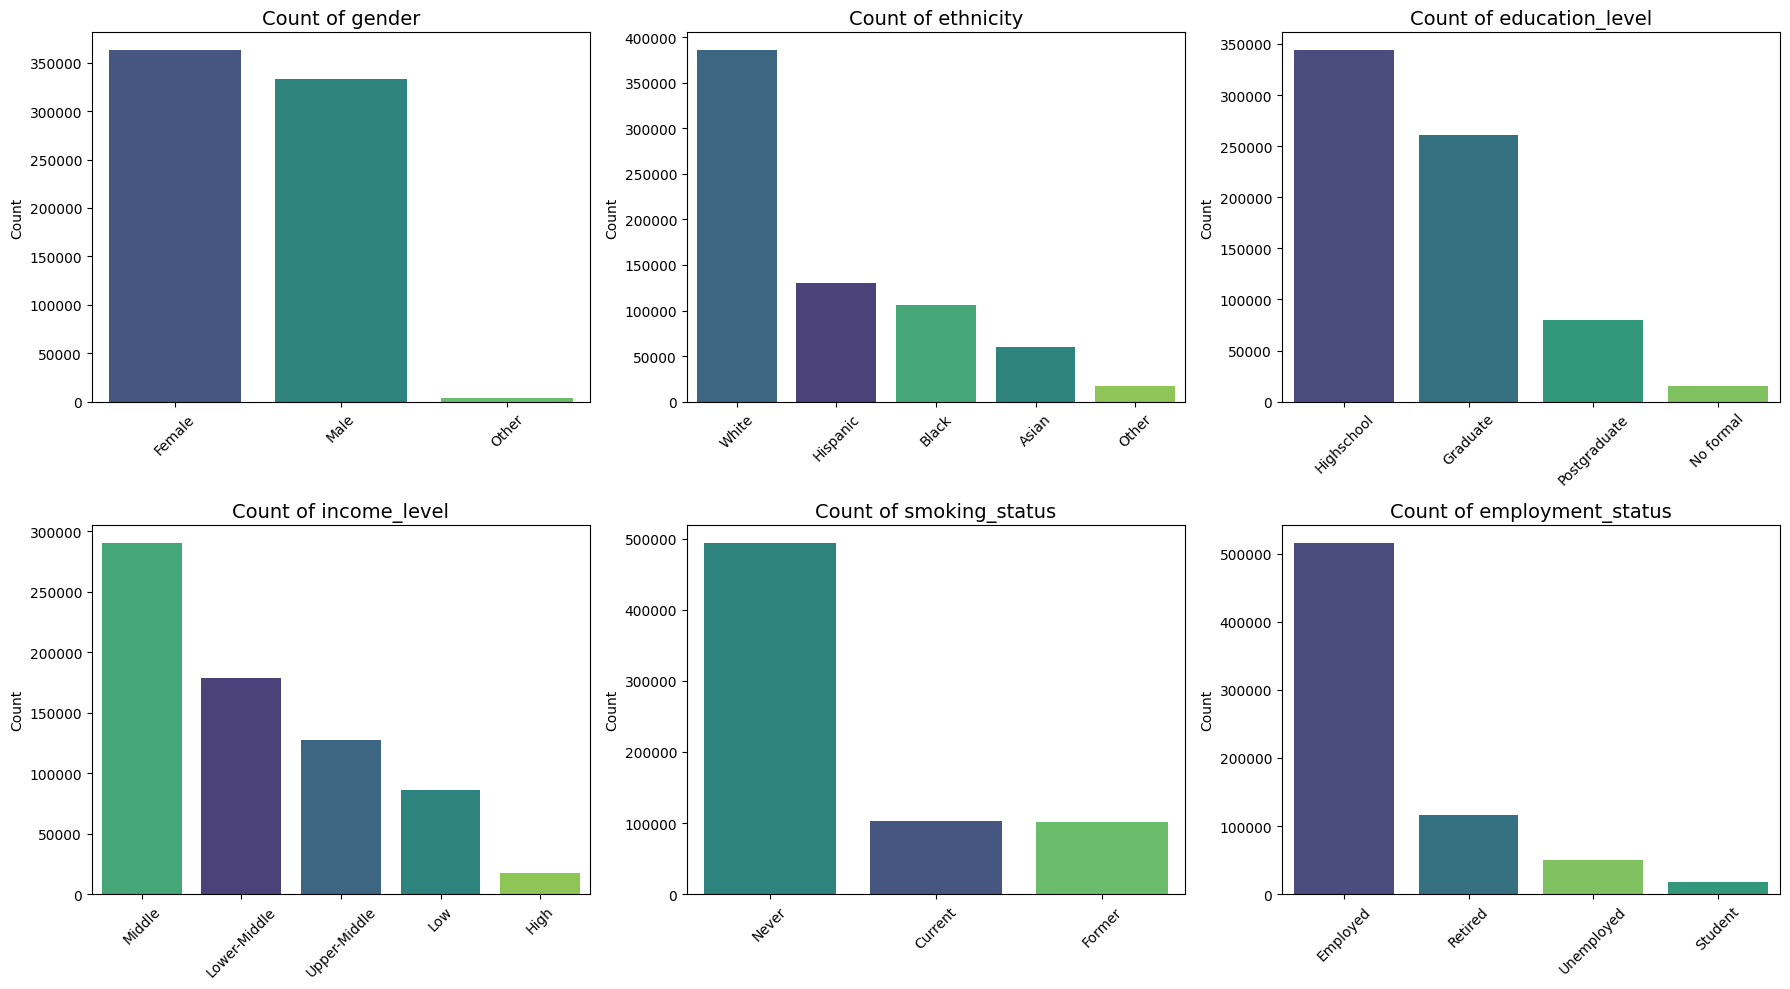

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    
    sns.countplot(data=df, x = col, order=order, ax=axes[i], palette="viridis", hue=col, legend=False)
    axes[i].set_title(f'Count of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
for col in cat_cols:
    ol = df[col].value_counts().index.tolist()
    mapping = {label: i for i, label in enumerate(ol)}
    df[col] = df[col].map(mapping)
print(df[cat_cols].head())

   gender  ethnicity  education_level  income_level  smoking_status  \
0       0          1                0             1               1   
1       0          0                0             2               0   
2       1          1                0             1               0   
3       0          0                0             1               1   
4       1          0                0             2               0   

   employment_status  
0                  0  
1                  0  
2                  1  
3                  0  
4                  1  


In [17]:
cat_cols = test.select_dtypes(include=["object"]).columns


In [18]:
for col in cat_cols:
    ol = test[col].value_counts().index.tolist()
    mapping = {label: i for i, label in enumerate(ol)}
    test[col] = test[col].map(mapping)
print(test[cat_cols].head())

   gender  ethnicity  education_level  income_level  smoking_status  \
0       0          0                0             0               1   
1       0          0                0             0               0   
2       1          0                0             3               0   
3       1          0                1             0               1   
4       1          0                1             3               2   

   employment_status  
0                  0  
1                  2  
2                  0  
3                  0  
4                  2  


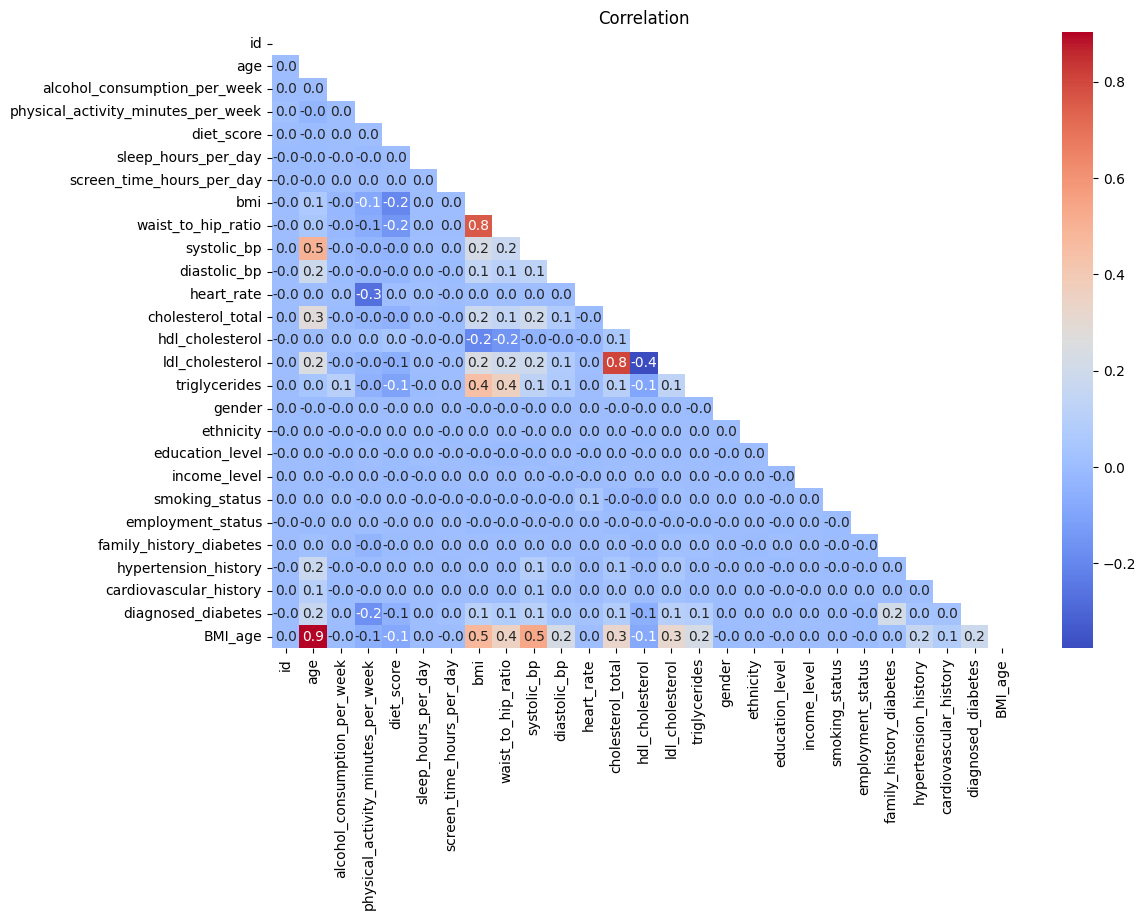

In [19]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix , mask = mask, annot = True,fmt = '.1f', annot_kws={"fontsize":10}, cmap='coolwarm',)

plt.title('Correlation')
plt.show()

In [20]:
df['waist_bmi'] = df['waist_to_hip_ratio'] * df['bmi']
df['systolic_age'] = df['systolic_bp'] * df['age']

In [21]:
scaler = MinMaxScaler()
X = df.copy()
X[num_cols] = scaler.fit_transform(X[num_cols])
X.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,BMI_age,waist_bmi,systolic_age
0,0.000000,0.171429,0.000,0.058981,0.775510,0.544118,0.345912,0.785408,0.675676,0.291667,...,1,1,0,0.0,0.0,0.0,1.0,0.269719,31.062,3472
1,0.000001,0.442857,0.125,0.096515,0.571429,0.500000,0.327044,0.373391,0.405405,0.402778,...,2,0,0,0.0,0.0,0.0,1.0,0.326436,19.754,6000
2,0.000003,0.185714,0.250,0.210456,0.857143,0.632353,0.534591,0.386266,0.405405,0.055556,...,1,0,1,0.0,0.0,0.0,0.0,0.172793,20.003,3040
3,0.000004,0.500000,0.250,0.101877,0.459184,0.573529,0.540881,0.493562,0.405405,0.416667,...,1,1,0,0.0,1.0,0.0,1.0,0.416832,22.078,6534
4,0.000006,0.500000,0.000,0.072386,0.571429,0.455882,0.283019,0.587983,0.594595,0.236111,...,2,0,1,0.0,1.0,0.0,1.0,0.460415,25.920,5832


In [22]:
scaler_z = StandardScaler()
Z = X.copy()
Z[num_cols] = scaler_z.fit_transform(X[num_cols])
Z[cat_cols] = scaler_z.fit_transform(X[cat_cols])

Z.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes,BMI_age,waist_bmi,systolic_age
0,-1.732048,-1.660994,-1.023109,-0.688168,1.186539,-0.224192,0.043144,2.630583,1.875577,-0.390013,...,-0.075851,0.763753,-0.527207,-0.419097,-0.471677,-0.176841,0.777416,-0.783064,31.062,3472
1,-1.732043,-0.030864,-0.069082,-0.141240,-0.180201,-0.556820,-0.105172,-0.725236,-0.757399,0.336574,...,0.800501,-0.599191,-0.527207,-0.419097,-0.471677,-0.176841,0.777416,-0.334257,19.754,6000
2,-1.732038,-1.575198,0.884944,1.519077,1.733236,0.441066,1.526305,-0.620366,-0.757399,-1.934010,...,-0.075851,-0.599191,0.838448,-0.419097,-0.471677,-0.176841,-1.286313,-1.550040,20.003,3040
3,-1.732033,0.312321,0.884944,-0.063108,-0.931908,-0.002439,1.575744,0.253545,-0.757399,0.427397,...,-0.075851,0.763753,-0.527207,-0.419097,2.120096,-0.176841,0.777416,0.381046,22.078,6534
4,-1.732029,0.312321,-1.023109,-0.492837,-0.180201,-0.889449,-0.451244,1.022587,1.085684,-0.753307,...,0.800501,-0.599191,0.838448,-0.419097,2.120096,-0.176841,0.777416,0.725924,25.920,5832


In [23]:
x = Z.drop(columns=['diagnosed_diabetes'])
y = df['diagnosed_diabetes']

In [24]:
x

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,BMI_age,waist_bmi,systolic_age
0,-1.732048,-1.660994,-1.023109,-0.688168,1.186539,-0.224192,0.043144,2.630583,1.875577,-0.390013,...,-0.874124,-0.075851,0.763753,-0.527207,-0.419097,-0.471677,-0.176841,-0.783064,31.062,3472
1,-1.732043,-0.030864,-0.069082,-0.141240,-0.180201,-0.556820,-0.105172,-0.725236,-0.757399,0.336574,...,-0.874124,0.800501,-0.599191,-0.527207,-0.419097,-0.471677,-0.176841,-0.334257,19.754,6000
2,-1.732038,-1.575198,0.884944,1.519077,1.733236,0.441066,1.526305,-0.620366,-0.757399,-1.934010,...,-0.874124,-0.075851,-0.599191,0.838448,-0.419097,-0.471677,-0.176841,-1.550040,20.003,3040
3,-1.732033,0.312321,0.884944,-0.063108,-0.931908,-0.002439,1.575744,0.253545,-0.757399,0.427397,...,-0.874124,-0.075851,0.763753,-0.527207,-0.419097,2.120096,-0.176841,0.381046,22.078,6534
4,-1.732029,0.312321,-1.023109,-0.492837,-0.180201,-0.889449,-0.451244,1.022587,1.085684,-0.753307,...,-0.874124,0.800501,-0.599191,0.838448,-0.419097,2.120096,-0.176841,0.725924,25.920,5832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,1.732029,-1.832587,-1.023109,-0.414704,0.639843,-1.998212,-2.231038,0.078763,0.559089,1.517278,...,1.755459,0.800501,2.126697,-0.527207,-0.419097,-0.471677,-0.176841,-1.591553,22.968,3857
699996,1.732033,-0.374049,-0.069082,-0.160773,1.186539,0.773695,-1.093947,-0.130976,-0.230804,-0.934953,...,0.440668,0.800501,2.126697,-0.527207,-0.419097,-0.471677,5.654809,-0.383609,21.675,4876
699997,1.732038,-1.317809,-1.023109,-0.590503,-0.248538,-1.000325,0.191460,0.358414,0.559089,0.972337,...,0.440668,-0.952203,-0.599191,-0.527207,-0.419097,-0.471677,-0.176841,-1.055657,23.672,4445
699998,1.732043,-0.116660,-0.069082,-0.199840,-0.180201,-0.113315,-0.648998,-0.235846,0.032494,-0.026720,...,-0.874124,-0.075851,-0.599191,0.838448,-0.419097,-0.471677,-0.176841,-0.204202,21.672,5684


In [25]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [26]:
X_train.shape

(560000, 28)

In [27]:
y.value_counts()

diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

In [28]:
test['BMI_age'] = test['bmi'] * test['age']
test['waist_bmi'] = test['waist_to_hip_ratio'] * test['bmi']
test['systolic_age'] = test['systolic_bp'] * test['age']

In [29]:
test.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'BMI_age', 'waist_bmi', 'systolic_age'],
      dtype='object')

In [30]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,              # Standard starting depth for XGB
    subsample=0.8,            # Uses 80% of data per tree to prevent overfitting
    colsample_bytree=0.8,     # Uses 80% of features per tree
    eval_metric='logloss',    # Standard for binary classification
    early_stopping_rounds=50, # Stops if no improvement in 50 rounds
    random_state=42,
)

# 4. Train the Model
# We pass the eval_set to monitor performance during training
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False             # Set to True if you want to see the error at each step
)

# 5. Predict and Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6842
ROC-AUC Score: 0.6322

Classification Report:
               precision    recall  f1-score   support

         0.0       0.62      0.42      0.50     52629
         1.0       0.71      0.84      0.77     87371

    accuracy                           0.68    140000
   macro avg       0.66      0.63      0.64    140000
weighted avg       0.67      0.68      0.67    140000



In [31]:
y_prob

array([0.34748048, 0.3475709 , 0.44540444, ..., 0.326251  , 0.4251167 ,
       0.442643  ], dtype=float32)

In [32]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

# 1. Setup Parameters
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize arrays to store results
# OOF: Predictions for the training set (used for validation score)
oof_lgb = np.zeros(len(X)) 
# pred_lgb: Predictions for the unseen test set
pred_lgb = np.zeros(len(test))

# 2. The Cross-Validation Loop
# enumerate gives us the fold number, (trn_idx, val_idx) gives the row positions
for fold, (trn_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Training Fold {fold + 1}...")
    
    # Split the data
    X_train, y_train = X.iloc[trn_idx], y.iloc[trn_idx]
    X_valid, y_valid = X.iloc[val_idx], y.iloc[val_idx]

    # Initialize the LightGBM Classifier
    model = LGBMClassifier(
        n_estimators=1500,
        learning_rate=0.02,
        num_leaves=64,
        colsample_bytree=0.8,
        subsample=0.8,
        random_state=42,
        predict_disable_shape_check=True,
        class_weight="balanced",
        verbosity=-1 # Hides unnecessary logs
    )

    # Train the model
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=100)]
    )

    # Store validation predictions (OOF)
    # [:, 1] gets the probability of the positive class (1)
    oof_lgb[val_idx] = model.predict_proba(X_valid)[:, 1]
    
    # Add test set predictions (divided by number of folds to get the average)
    pred_lgb += model.predict_proba(test)[:, 1] / n_splits

# 3. Evaluation
final_auc = roc_auc_score(y, oof_lgb)
print(f"\nOverall OOF ROC-AUC: {final_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


Training Fold 1...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 1	valid_0's binary_logloss: 0.671939
Training Fold 2...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 1	valid_0's binary_logloss: 0.671941
Training Fold 3...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 1	valid_0's binary_logloss: 0.671972
Training Fold 4...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 1	valid_0's binary_logloss: 0.671968
Training Fold 5...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 1	valid_0's binary_logloss: 0.671916

Overall OOF ROC-AUC: 1.0000


In [33]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Setup K-Fold
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
oof_ensemble = np.zeros(len(x))
final_preds = np.zeros(len(test))

# 2. Cross-Validation Loop
for fold, (trn_idx, val_idx) in enumerate(kf.split(x, y)):
    print(f"--- Training Fold {fold + 1} ---")
    
    # Split the data
    X_train, y_train = x.iloc[trn_idx], y.iloc[trn_idx]
    X_valid, y_valid = x.iloc[val_idx], y.iloc[val_idx]
    
    # CRITICAL: Ensure 'test' has the exact same columns/order as 'x'
    # This prevents the KeyError and the XGBoost feature mismatch
    test_aligned = test[X_train.columns]

    # --- Model A: LightGBM ---
    lgb_model = lgb.LGBMClassifier(
        n_estimators=1500, 
        learning_rate=0.05, 
        num_leaves=64, 
        verbosity=-1,           # This handles the internal LightGBM logging
        class_weight='balanced',
        random_state=42
    )
    
    lgb_model.fit(
        X_train, y_train, 
        eval_set=[(X_valid, y_valid)], 
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(period=0) # This replaces verbose=False
        ]
    )
    
    # --- Model B: XGBoost ---
    xgb_model = XGBClassifier(
        n_estimators=1500, 
        learning_rate=0.05, 
        max_depth=6, 
        eval_metric='logloss',
        early_stopping_rounds=100,
        random_state=42
    )
    xgb_model.fit(
        X_train, y_train, 
        eval_set=[(X_valid, y_valid)], 
        verbose=False
    )

    # --- Model C: CatBoost ---
    cat_model = CatBoostClassifier(
        iterations=1500, 
        learning_rate=0.05, 
        depth=6, 
        eval_metric='AUC',
        early_stopping_rounds=100,
        random_seed=42,
        verbose=False
    )
    cat_model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

    # 3. Weighted Blending (OOF)
    lgb_val = lgb_model.predict_proba(X_valid)[:, 1]
    xgb_val = xgb_model.predict_proba(X_valid)[:, 1]
    cat_val = cat_model.predict_proba(X_valid)[:, 1]
    
    # Weighted Average for OOF
    oof_ensemble[val_idx] = (0.4 * lgb_val) + (0.3 * xgb_val) + (0.3 * cat_val)

    # 4. Predict on Test and Average
    lgb_test = lgb_model.predict_proba(test_aligned)[:, 1]
    xgb_test = xgb_model.predict_proba(test_aligned)[:, 1]
    cat_test = cat_model.predict_proba(test_aligned)[:, 1]
    
    final_preds += ((0.4 * lgb_test) + (0.3 * xgb_test) + (0.3 * cat_test)) / n_splits

# 5. Final Result
print(f"\nFinal Ensemble OOF AUC: {roc_auc_score(y, oof_ensemble):.4f}")

--- Training Fold 1 ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[676]	valid_0's auc: 0.726756	valid_0's binary_logloss: 0.607198
--- Training Fold 2 ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[624]	valid_0's auc: 0.724894	valid_0's binary_logloss: 0.608964
--- Training Fold 3 ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[950]	valid_0's auc: 0.725712	valid_0's binary_logloss: 0.607608
--- Training Fold 4 ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[704]	valid_0's auc: 0.726364	valid_0's binary_logloss: 0.60754
--- Training Fold 5 ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[697]	valid_0's auc: 0.726507	valid_0's binary_logloss: 0.60775

Final Ensemble OOF AUC: 0.7270


In [34]:
test.shape

(300000, 28)

In [35]:
x.shape

(700000, 28)

In [36]:
final_preds       

array([0.57589281, 0.50447118, 0.50935542, ..., 0.58390701, 0.50034131,
       0.52809535])

In [37]:
sub = pd.read_csv("/kaggle/input/playground-series-s5e12/sample_submission.csv")
sub.head()

,id,diagnosed_diabetes
0,700000,0
1,700001,0
2,700002,0
3,700003,0
4,700004,0


In [38]:
sub['diagnosed_diabetes'].value_counts()

diagnosed_diabetes
0    300000
Name: count, dtype: int64

In [39]:
submission = pd.DataFrame({
    "id": test['id'],
    "diagnosed_diabetes": final_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully!")

submission.csv saved successfully!
